# Clinical Cohort Analysis with Monte Carlo Cross-Validation

**Study Replication:** Publication-quality cohort-specific analysis with Monte Carlo cross-validation (configurable 50–100 splits)  
**Updated:** November 21, 2025  
**Hardware:** Optimized for 32-core EC2 instance (1TB RAM)  
**Validation:** Proper evaluation on unseen test data

## Key Changes from Original

✅ **Clinical Cohort Analysis** – CHD vs MyoCardio cohorts with modifiable clinical features  
✅ **Survival Analysis Mode** – Time-to-event analysis with survival models (RSF, AORSF, CatBoost-Cox, XGBoost-Cox)  
✅ **Monte Carlo Cross-Validation** – 50–100 random 80/20 train/test splits for cohort-level analysis  
✅ **Stratified Sampling** - Maintains event distribution  
✅ **Parallel Processing** - Fast execution with furrr/future (≈30 workers)  
✅ **95% Confidence Intervals** - Narrow, precise estimates (tighter with more splits)  
✅ **Realistic C-Indexes** - Expected range 0.70-0.85

## Methodology

This notebook implements the feature selection methodology from the original bcjaeger/graft-loss study:

1. Load data for pediatric heart transplant outcomes
2. Define three time periods:
   - **Original**: 2010-2019 (matches publication)
   - **Full**: 2010-2024 (all available data)
   - **Full No COVID**: 2010-2024 excluding 2020-2023
3. For each period and method:
   - Create 100–1000 stratified train/test splits (75/25)
   - Train model on training set
   - Evaluate on unseen test set
   - Aggregate results across splits
4. Calculate C-index with 95% CI
5. Extract top 20 features

## Expected Runtime (per full 3-period × 3-method run)

- **100 splits (current default):**
  - Local (4 cores): ~2–4 hours (NOT RECOMMENDED)
  - Workstation (16 cores): ~1–2 hours
  - EC2 (32 cores, 1TB RAM): ~1–2 hours ✅ **RECOMMENDED FOR DEVELOPMENT**
- **1000 splits (extended / publication-level):**
  - Local (4 cores): 8–12+ hours (NOT RECOMMENDED)
  - Workstation (16 cores): ~8–16 hours
  - EC2 (32 cores, 1TB RAM): ~10–20 hours ✅ **RECOMMENDED FOR FINAL RESULTS**


In [1]:
# Check R version
R.version.string

# Load required packages
library(here)
library(dplyr)
library(readr)
library(survival)
library(ranger)
library(aorsf)
library(catboost)
library(tidyr)
library(purrr)
library(tibble)
library(janitor)
library(haven)
library(riskRegression)
library(prodlim)
library(rsample)    # For MC-CV
library(furrr)      # For parallel processing
library(future)     # For parallel backend
library(progressr)  # For progress bars
library(xgboost)     # For XGBoost survival models

# Source survival helper functions (needed for consistent model fitting)
source(here("scripts", "R", "survival_helpers.R"))
cat("✓ Survival helper functions loaded\n")

# Load classification packages (needed for classification mode)
if (exists("ANALYSIS_MODE") && ANALYSIS_MODE == "classification") {
  library(glmnet)      # For LASSO
  library(randomForest) # For Traditional RF
  library(pROC)         # For AUC calculation
  library(cutpointr)    # For threshold optimization
  source(here("scripts", "R", "classification_helpers.R"))
  cat("✓ Classification packages loaded\n")
}

cat("✓ All packages loaded successfully\n")


[1] "R version 4.4.3 (2025-02-28)"

here() starts at /home/pgx3874/graft-loss


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test


riskRegression version 2025.09.17

Loading required package: future


Attaching package: ‘future’


The following object is masked from ‘package:survival’:

    cluster



Attaching package: ‘xgboost’


The following object is masked from ‘package:dplyr’:

    slice




✓ Survival helper functions loaded
✓ All packages loaded successfully


In [2]:
# Create output directory
output_dir <- here("cohort_analysis", "outputs", "survival")

# IDEMPOTENCY: Skip existing outputs if enabled
# Set SKIP_EXISTING_OUTPUTS = TRUE to resume from where you left off
# Set SKIP_EXISTING_OUTPUTS = FALSE to start fresh (will clean existing outputs)
SKIP_EXISTING_OUTPUTS <- TRUE  # Change to FALSE to force a fresh start

if (SKIP_EXISTING_OUTPUTS) {
  cat("\n")
  cat("╔════════════════════════════════════════════════════════════════╗\n")
  cat("║          🔄 RESUME MODE: Skipping existing outputs            ║\n")
  cat("╚════════════════════════════════════════════════════════════════╝\n")
  cat("Set SKIP_EXISTING_OUTPUTS = FALSE to force a fresh start\n\n")
} else {
  cat("\n")
  cat("╔════════════════════════════════════════════════════════════════╗\n")
  cat("║          🧹 FRESH START MODE: Cleaning existing outputs       ║\n")
  cat("╚════════════════════════════════════════════════════════════════╝\n\n")
  
  # Clean existing outputs directory to ensure fresh/clean results
  if (dir.exists(output_dir)) {
    # Remove all files in outputs directory
    output_files <- list.files(output_dir, full.names = TRUE, recursive = TRUE, include.dirs = FALSE)
    if (length(output_files) > 0) {
      cat(sprintf("Cleaning %d existing output files...\n", length(output_files)))
      file.remove(output_files)
    }
    # Remove empty subdirectories
    output_dirs <- list.dirs(output_dir, recursive = TRUE, full.names = TRUE)
    output_dirs <- output_dirs[output_dirs != output_dir]  # Don't remove main directory
    for (dir in rev(output_dirs)) {  # Reverse order to remove nested dirs first
      if (length(list.files(dir)) == 0) {
        unlink(dir, recursive = TRUE)
      }
    }
    cat("✓ Output directory cleaned\n")
  }
}

# Create output directory (if it doesn't exist)
dir.create(output_dir, showWarnings = FALSE, recursive = TRUE)

cat("Output directory:", output_dir, "\n")
cat("MC-CV configuration will be displayed after setup is complete.
")
flush.console()


╔════════════════════════════════════════════════════════════════╗
║          🔄 RESUME MODE: Skipping existing outputs            ║
╚════════════════════════════════════════════════════════════════╝
Set SKIP_EXISTING_OUTPUTS = FALSE to force a fresh start

Output directory: /home/pgx3874/graft-loss/cohort_analysis/outputs/survival 
MC-CV configuration will be displayed after setup is complete.


## 1. Setup and Configuration

Load required packages and configure parallel processing.


In [3]:
# ============================================================
# DEBUG/TEST MODE - Quick testing before full 100-split run
# ============================================================
# Set DEBUG_MODE = TRUE for quick testing (5 splits, ~2-5 min)
# Set DEBUG_MODE = FALSE for full analysis (100 splits, ~1-2 hours on EC2)
DEBUG_MODE <- FALSE  # Change to TRUE for quick test

# Analysis Mode: "survival" or "classification"
# - "survival": Time-to-event analysis with survival models (RSF, AORSF, CatBoost-Cox, XGBoost-Cox)
# - "classification": Binary classification at 1 year (LASSO, CatBoost, CatBoost RF, Traditional RF)
# Survival Analysis Mode (fixed)

# Analysis Mode: Survival Analysis (time-to-event)
if (DEBUG_MODE) {
  cat("\n")
  cat("╔════════════════════════════════════════════════════════════════╗\n")
  cat("║                    🔍 DEBUG MODE ENABLED                       ║\n")
  cat("╚════════════════════════════════════════════════════════════════╝\n")
  cat("\n")
  cat("Quick test configuration:\n")
  cat("  • MC-CV Splits: 5 (instead of 100)\n")
  cat("  • Period: Original only (2010-2019)\n")
  cat("  • Trees: Reduced (RSF: 100, AORSF: 50)\n")
  cat("  • Expected time: 2-5 minutes\n")
  cat("  • Purpose: Verify everything works before full run\n")
  cat("\n")
  cat("To run full analysis, set DEBUG_MODE = FALSE\n")
  cat("\n")
}

# Configuration
n_predictors <- 20                                        # Top 20 features
n_trees_rsf <- if (DEBUG_MODE) 100 else 500              # RSF trees (reduced in debug)
n_trees_aorsf <- if (DEBUG_MODE) 50 else 100             # AORSF trees (reduced in debug)
horizon <- 1                                              # 1-year prediction
n_mc_splits <- if (DEBUG_MODE) 5 else 100                # MC-CV splits (5 for debug, 100 for full)
train_prop <- 0.75                                        # 75% training, 25% testing

# Set up parallel processing - EC2 Optimized (32 cores, 1TB RAM)
# Use 30 out of 32 cores (leave 2 for system)
n_workers <- as.integer(Sys.getenv("N_WORKERS", "0"))
if (n_workers < 1) {
  total_cores <- parallel::detectCores()
  n_workers <- max(1, total_cores - 2)
  cat(sprintf("Auto-detected %d cores, using %d workers\n", total_cores, n_workers))
}

cat(sprintf("Setting up parallel processing with %d workers...\n", n_workers))
cat(sprintf("Expected speedup: %dx faster than single core\n", round(n_workers * 0.8)))

# Increase future.globals.maxSize for large MC-CV splits object
# With 1TB RAM on EC2, we can handle large transfers
options(future.globals.maxSize = 20 * 1024^3)  # 20 GB limit (plenty for 100 splits)
cat("Set future.globals.maxSize to 20 GB\n")

plan(multisession, workers = n_workers)

# Output directory is already created in Cell 2 with idempotency logic
# Just ensure it exists (don't clean it here - that's handled by SKIP_EXISTING_OUTPUTS in Cell 2)
output_dir <- here("cohort_analysis", "outputs", "survival")
dir.create(output_dir, showWarnings = FALSE, recursive = TRUE)

cat("Output directory:", output_dir, "\n")
cat(sprintf("MC-CV Configuration: %d splits, %.0f/%.0f train/test split\n", 
            n_mc_splits, train_prop * 100, (1 - train_prop) * 100))
flush.console()


Auto-detected 32 cores, using 30 workers
Setting up parallel processing with 30 workers...
Expected speedup: 24x faster than single core
Set future.globals.maxSize to 20 GB
Output directory: /home/pgx3874/graft-loss/cohort_analysis/outputs/survival 
MC-CV Configuration: 100 splits, 75/25 train/test split


## 2. Helper Functions

Define functions for data preparation, C-index calculation, and prediction.


In [4]:
# Prepare modeling data with leakage prevention
# Supports both survival and classification modes
prepare_modeling_data <- function(data, mode = "survival") {
  if (mode == "survival") {
    # Survival mode: Find time and status columns
    time_col <- intersect(c("time", "outcome_int_graft_loss", "int_graft_loss"), names(data))[1]
    status_col <- intersect(c("status", "outcome_graft_loss", "graft_loss"), names(data))[1]
    
    if (is.na(time_col) || is.na(status_col)) {
      stop("Cannot find time/status columns for survival mode")
    }
    
    # Rename to standard names
    if (time_col != "time") data <- data %>% rename(time = !!time_col)
    if (status_col != "status") data <- data %>% rename(status = !!status_col)
  } else if (mode == "classification") {
    # Classification mode: Find outcome column
    outcome_col <- intersect(c("outcome", "outcome_1yr", "event_1yr"), names(data))[1]
    
    if (is.na(outcome_col)) {
      # Try to create outcome from time/status if available
      if ("ev_time" %in% names(data) && "ev_type" %in% names(data)) {
        data <- data %>%
          mutate(
            outcome = case_when(
              ev_type == 1 & ev_time < 1 ~ 1L,  # Event by 1 year
              ev_type == 0 & ev_time >= 1 ~ 0L,  # No event, follow-up >= 1 year
              TRUE ~ NA_integer_  # Censored before 1 year - drop
            )
          ) %>%
          filter(!is.na(outcome))  # Drop censored before 1 year
        cat("→ Created outcome variable from ev_time and ev_type\n")
      } else {
        stop("Cannot find outcome column or ev_time/ev_type for classification mode")
      }
    } else if (outcome_col != "outcome") {
      data <- data %>% rename(outcome = !!outcome_col)
    }
  } else {
    stop("Invalid ANALYSIS_MODE. Must be 'survival' or 'classification'")
  }
  
  # Exclude leakage variables and identifier columns
  exclude_exact <- c(
    "ID", "ptid_e", "int_dead", "int_death", "graft_loss", "txgloss", "death", "event",
    "dpricaus", "deathspc", "concod", "age_death", "dlist", "txpl_year",
    "rrace_b", "rrace_a", "rrace_ai", "rrace_pi", "rrace_o", "rrace_un", "race",
    "patsupp", "pmorexam", "papooth", "pacuref", "pishltgr",
    "pathero", "pcadrec", "pcadrem", "pdiffib", "cpathneg",
    "dcardiac", "dneuro", "dreject", "dsecaccs", "dpriaccs",
    "dconmbld", "dconmal", "dconcard", "dconneur", "dconrej",
    "dmajbld", "dmalcanc"
  )
  
  exclude_prefixes <- c("dtx_", "cc_", "dcon", "dpri", "dsec", "dmaj", "sd")
  
  exclude_by_prefix <- character(0)
  for (prefix in exclude_prefixes) {
    exclude_by_prefix <- c(exclude_by_prefix, 
                           names(data)[startsWith(names(data), prefix)])
  }
  
  exclude_all <- unique(c(exclude_exact, exclude_by_prefix))
  data <- data %>% select(-any_of(exclude_all))
  
  # Median imputation for numeric variables
  numeric_vars <- names(data)[sapply(data, is.numeric) & names(data) != "time" & names(data) != "status"]
  for (var in numeric_vars) {
    if (any(is.na(data[[var]]))) {
      median_val <- median(data[[var]], na.rm = TRUE)
      data[[var]][is.na(data[[var]])] <- median_val
    }
  }
  
  # Mode imputation for categorical variables
  categorical_vars <- names(data)[sapply(data, function(x) is.factor(x) | is.character(x))]
  for (var in categorical_vars) {
    if (any(is.na(data[[var]]))) {
      mode_val <- names(sort(table(data[[var]]), decreasing = TRUE))[1]
      data[[var]][is.na(data[[var]])] <- mode_val
    }
  }
  
  # Remove constant columns
  constant_cols <- names(data)[sapply(data, function(x) length(unique(na.omit(x))) <= 1)]
  if (length(constant_cols) > 0) {
    data <- data %>% select(-any_of(constant_cols))
  }
  
  # Convert character to factor
  data <- data %>% mutate(across(where(is.character), as.factor))
  
  return(data)
}

cat("✓ prepare_modeling_data() defined\n")


✓ prepare_modeling_data() defined


In [5]:
# C-index calculation
calculate_cindex <- function(time, status, risk_scores, horizon = NULL) {
  valid_idx <- !is.na(time) & !is.na(status) & !is.na(risk_scores) &
               is.finite(time) & is.finite(risk_scores) & time > 0
  
  time   <- as.numeric(time[valid_idx])
  status <- as.numeric(status[valid_idx])
  risk   <- as.numeric(risk_scores[valid_idx])
  
  n <- length(time)
  events <- sum(status == 1)
  
  if (n < 10 || events < 1 || length(unique(risk)) == 1) {
    return(list(cindex_td = NA_real_, cindex_ti = NA_real_))
  }
  
  # Time-independent C-index (Harrell's)
  num_conc_ti <- 0
  num_disc_ti <- 0
  num_ties_ti <- 0
  
  for (i in seq_len(n)) {
    if (status[i] != 1) next
    for (j in seq_len(n)) {
      if (i == j) next
      if (time[i] < time[j]) {
        if (risk[i] > risk[j]) {
          num_conc_ti <- num_conc_ti + 1
        } else if (risk[i] < risk[j]) {
          num_disc_ti <- num_disc_ti + 1
        } else {
          num_ties_ti <- num_ties_ti + 1
        }
      }
    }
  }
  
  denom_ti <- num_conc_ti + num_disc_ti + num_ties_ti
  cindex_ti <- if (denom_ti > 0) (num_conc_ti + 0.5 * num_ties_ti) / denom_ti else NA_real_
  
  # Time-dependent C-index
  cindex_td <- tryCatch({
    score_data <- data.frame(time = time, status = status)
    pred_matrix <- matrix(risk, ncol = 1)
    
    evaluation <- riskRegression::Score(
      object = list(Model = pred_matrix),
      formula = Surv(time, status) ~ 1,
      data = score_data,
      times = if (!is.null(horizon)) horizon else median(time[status == 1]),
      summary = "risks",
      metrics = "auc",
      se.fit = FALSE
    )
    
    as.numeric(evaluation$AUC$score$AUC[1])
  }, error = function(e) cindex_ti)
  
  return(list(cindex_td = cindex_td, cindex_ti = cindex_ti))
}

# ranger_predictrisk function
ranger_predictrisk <- function(object, newdata, times) {
  preds <- predict(object, data = newdata, type = "response")
  if (is.null(preds$survival)) {
    stop("ranger prediction did not return survival probabilities")
  }
  
  surv_matrix <- preds$survival
  time_points <- preds$unique.death.times
  closest_idx <- which.min(abs(time_points - times))
  risk_scores <- 1 - surv_matrix[, closest_idx]
  
  return(as.numeric(risk_scores))
}

cat("✓ calculate_cindex() and ranger_predictrisk() defined\n")


✓ calculate_cindex() and ranger_predictrisk() defined


## 3. Monte Carlo Cross-Validation Function

Main function that runs MC-CV for a single method and period.


In [6]:
# Run MC-CV for a single method and time period
# Uses wrapper functions from survival_helpers.R for consistency with cohort analysis
run_mc_cv_method <- function(data, method, period_name, mc_splits) {
  
  cat(sprintf("\n=== Running MC-CV for %s (%s) ===\n", method, period_name))
  cat(sprintf("Splits: %d | Train: %.0f%% | Test: %.0f%%\n", 
              n_mc_splits, train_prop * 100, (1 - train_prop) * 100))
  flush.console()
  
  split_ids <- seq_len(n_mc_splits)
  
  # Run splits in parallel with progress bar
  with_progress({
    p <- progressor(steps = n_mc_splits)
    
    results <- future_map(split_ids, function(split_id) {
      p()  # Update progress
      
      # Get train/test data from split
      split <- mc_splits$splits[[split_id]]
      train_data <- rsample::analysis(split)
      test_data <- rsample::assessment(split)
      
      tryCatch({
        # Use wrapper functions from survival_helpers.R for consistency
        res <- NULL
        
        if (method == "RSF") {
          res <- run_rsf_ranger(
            train_df = train_data,
            test_df = test_data,
            time_col = "time",
            status_col = "status",
            cohort_name = period_name,
            model_name = "RSF",
            num.trees = n_trees_rsf
          )
        } else if (method == "AORSF") {
          res <- run_aorsf(
            train_df = train_data,
            test_df = test_data,
            time_col = "time",
            status_col = "status",
            cohort_name = period_name,
            model_name = "AORSF",
            n_tree = n_trees_aorsf
          )
        } else if (method == "CatBoost") {
          cb_params <- list(
            loss_function = "Cox",
            eval_metric   = "Cox",
            iterations    = 1200,
            depth         = 4,
            learning_rate = 0.1,
            thread_count  = 1,
            logging_level = "Silent",
            verbose       = 0L
          )
          res <- run_catboost_cox(
            train_df = train_data,
            test_df = test_data,
            time_col = "time",
            status_col = "status",
            cohort_name = period_name,
            model_name = "CatBoost",
            params = cb_params
          )
        } else if (method == "XGBoost") {
          xgb_params <- list(
            objective        = "survival:cox",
            eval_metric      = "cox-nloglik",
            eta              = 0.05,
            max_depth        = 4,
            subsample        = 0.8,
            colsample_bytree = 0.8
          )
          res <- run_xgb_cox(
            train_df = train_data,
            test_df = test_data,
            time_col = "time",
            status_col = "status",
            cohort_name = period_name,
            model_name = "XGBoost-Cox",
            params = xgb_params,
            nrounds = 400,
            early_stopping_rounds = 25
          )
        } else if (method == "XGBoost_RF") {
          xgb_rf_params <- list(
            objective         = "survival:cox",
            eval_metric       = "cox-nloglik",
            eta               = 1.0,
            max_depth         = 6,
            subsample         = 0.63,
            colsample_bytree  = 0.8,
            num_parallel_tree = 500
          )
          res <- run_xgb_cox(
            train_df = train_data,
            test_df = test_data,
            time_col = "time",
            status_col = "status",
            cohort_name = period_name,
            model_name = "XGBoost RF",
            params = xgb_rf_params,
            nrounds = 1,
            early_stopping_rounds = 0
          )
        } else {
          stop("Unknown method: ", method)
        }
        
        # Extract C-index from concordance object (time-independent)
        cindex_ti <- as.numeric(res$concordance$concordance)
        
        # Calculate time-dependent C-index using risk_scores
        cindex_result <- calculate_cindex(
          time = test_data$time,
          status = test_data$status,
          risk_scores = res$risk_scores,
          horizon = horizon
        )
        cindex_td <- cindex_result$cindex_td
        
        # Convert importance data.frame to named vector
        feature_importance <- NULL
        if (!is.null(res$importance) && nrow(res$importance) > 0) {
          feature_importance <- res$importance$importance
          names(feature_importance) <- res$importance$feature
        } else if (!is.null(res$vi) && nrow(res$vi) > 0) {
          # AORSF uses 'vi' instead of 'importance'
          feature_importance <- res$vi$importance
          names(feature_importance) <- res$vi$feature
        }
        
        return(list(
          split_id = split_id,
          cindex_td = cindex_td,
          cindex_ti = cindex_ti,
          feature_importance = feature_importance,
          n_train = nrow(train_data),
          n_test = nrow(test_data),
          success = TRUE
        ))
        
      }, error = function(e) {
        return(list(
          split_id = split_id,
          cindex_td = NA_real_,
          cindex_ti = NA_real_,
          feature_importance = NULL,
          n_train = nrow(train_data),
          n_test = nrow(test_data),
          success = FALSE,
          error = e$message
        ))
      })
    }, .options = furrr_options(
      seed = TRUE,
      packages = c(
        "dplyr", "purrr", "tibble", "rsample",
        "ranger", "aorsf", "catboost", "xgboost",
        "riskRegression", "prodlim"
      )
    ))
  })
  
  # Aggregate results
  successful_splits <- Filter(function(x) x$success, results)
  n_successful <- length(successful_splits)
  
  cat(sprintf("Successful splits: %d / %d\n", n_successful, n_mc_splits))
  flush.console()
  
  # If all splits failed (e.g., CatBoost configuration/data issue),
  # do not stop the whole analysis. Instead, log a warning and return
  # an empty/NA summary so that other methods and periods can continue.
  if (n_successful == 0) {
    error_splits <- Filter(function(x) !is.null(x$error), results)
    if (length(error_splits) > 0) {
      first_error <- error_splits[[1]]$error
      cat(sprintf("WARNING: example error for %s (%s): %s\n",
                  method, period_name, first_error))
    }
    cat(sprintf("WARNING: All MC-CV splits failed for %s (%s). Skipping this method.\n",
                method, period_name))
    flush.console()
    
    return(list(
      method = method,
      period = period_name,
      n_splits = n_mc_splits,
      n_successful = 0,
      cindex_td_mean = NA_real_,
      cindex_td_sd = NA_real_,
      cindex_td_ci_lower = NA_real_,
      cindex_td_ci_upper = NA_real_,
      cindex_ti_mean = NA_real_,
      cindex_ti_sd = NA_real_,
      cindex_ti_ci_lower = NA_real_,
      cindex_ti_ci_upper = NA_real_,
      top_features = numeric(0)
    ))
  }
  
  # Extract C-indexes
  cindex_td_values <- sapply(successful_splits, function(x) x$cindex_td)
  cindex_ti_values <- sapply(successful_splits, function(x) x$cindex_ti)
  
  cindex_td_values <- cindex_td_values[!is.na(cindex_td_values)]
  cindex_ti_values <- cindex_ti_values[!is.na(cindex_ti_values)]
  
  # Aggregate feature importance
  # All methods (RSF, AORSF, CatBoost) return named numeric vectors
  all_feature_names <- unique(unlist(lapply(successful_splits, function(x) {
    if (is.null(x$feature_importance)) return(NULL)
    names(x$feature_importance)
  })))
  
  aggregated_importance <- sapply(all_feature_names, function(feature) {
    importances <- sapply(successful_splits, function(x) {
      if (is.null(x$feature_importance)) return(NA_real_)
      if (feature %in% names(x$feature_importance)) {
        return(as.numeric(x$feature_importance[feature]))
      }
      return(NA_real_)
    })
    mean(importances, na.rm = TRUE)
  })
  
  # Ensure aggregated_importance is a numeric vector
  aggregated_importance <- as.numeric(aggregated_importance)
  names(aggregated_importance) <- all_feature_names
  
  top_features <- sort(aggregated_importance, decreasing = TRUE)[1:min(n_predictors, length(aggregated_importance))]
  
  # Calculate statistics
  results_summary <- list(
    method = method,
    period = period_name,
    n_splits = n_mc_splits,
    n_successful = n_successful,
    cindex_td_mean = mean(cindex_td_values, na.rm = TRUE),
    cindex_td_sd = sd(cindex_td_values, na.rm = TRUE),
    cindex_td_ci_lower = quantile(cindex_td_values, 0.025, na.rm = TRUE),
    cindex_td_ci_upper = quantile(cindex_td_values, 0.975, na.rm = TRUE),
    cindex_ti_mean = mean(cindex_ti_values, na.rm = TRUE),
    cindex_ti_sd = sd(cindex_ti_values, na.rm = TRUE),
    cindex_ti_ci_lower = quantile(cindex_ti_values, 0.025, na.rm = TRUE),
    cindex_ti_ci_upper = quantile(cindex_ti_values, 0.975, na.rm = TRUE),
    top_features = top_features
  )
  
  # Print summary
  cat(sprintf("\n--- Results for %s (%s) ---\n", method, period_name))
  cat(sprintf("Time-Dependent C-Index: %.4f ± %.4f (95%% CI: %.4f - %.4f)\n",
              results_summary$cindex_td_mean,
              results_summary$cindex_td_sd,
              results_summary$cindex_td_ci_lower,
              results_summary$cindex_td_ci_upper))
  cat(sprintf("Time-Independent C-Index: %.4f ± %.4f (95%% CI: %.4f - %.4f)\n",
              results_summary$cindex_ti_mean,
              results_summary$cindex_ti_sd,
              results_summary$cindex_ti_ci_lower,
              results_summary$cindex_ti_ci_upper))
  # Display top 10 features sorted alphabetically for easier comparison
  top10_features <- names(top_features)[1:min(10, length(top_features))]
  top10_features_sorted <- sort(top10_features)
  cat(sprintf("Top 10 features (alphabetical): %s\n", paste(top10_features_sorted, collapse = ", ")))
  flush.console()
  
  return(results_summary)
}

cat("✓ run_mc_cv_method() defined\n")


✓ run_mc_cv_method() defined


## 4. Load Data

In [7]:
# Find and load SAS file
sas_path_local <- here("data", "phts_txpl_ml.sas7bdat")
sas_path_external <- here("graft-loss-parallel-processing", "data", "phts_txpl_ml.sas7bdat")
sas_path_graft_loss <- here("graft-loss", "data", "phts_txpl_ml.sas7bdat")

sas_path <- NULL
for (path in c(sas_path_local, sas_path_external, sas_path_graft_loss)) {
  if (file.exists(path)) {
    sas_path <- path
    break
  }
}

if (is.null(sas_path)) {
  stop("Cannot find phts_txpl_ml.sas7bdat in any location")
}

cat("Loading data from:", sas_path, "\n")

# Load data
phts_base <- haven::read_sas(sas_path) %>%
  filter(TXPL_YEAR >= 2010) %>%
  janitor::clean_names() %>%
  rename(
    outcome_int_graft_loss = int_graft_loss,
    outcome_graft_loss = graft_loss,
    primary_etiology = prim_dx  # Rename prim_dx to primary_etiology for cohort filtering
  ) %>%
  mutate(
    ID = 1:n(),
    across(.cols = where(is.character), ~ ifelse(.x %in% c("", "unknown", "missing"), NA_character_, .x)),
    across(.cols = where(is.character), as.factor),
    tx_mcsd = if ('txnomcsd' %in% names(.)) {
      if_else(txnomcsd == 'yes', 0, 1)
    } else if ('txmcsd' %in% names(.)) {
      txmcsd
    } else {
      NA_real_
    }
  )

cat(sprintf("✓ Loaded data: %d rows, %d columns\n", nrow(phts_base), ncol(phts_base)))


Loading data from: /home/pgx3874/graft-loss/data/phts_txpl_ml.sas7bdat 
✓ Loaded data: 5835 rows, 478 columns


In [8]:
# Define time periods
periods <- list()
periods$original <- phts_base %>% filter(txpl_year >= 2010 & txpl_year <= 2019)
periods$full <- phts_base %>% filter(txpl_year >= 2010)
periods$full_no_covid <- phts_base %>% filter(txpl_year >= 2010 & !(txpl_year >= 2020 & txpl_year <= 2023))

# Print summary
for (period_name in names(periods)) {
  period_data <- periods[[period_name]]
  n_events <- sum(period_data$outcome_graft_loss, na.rm = TRUE)
  event_rate <- 100 * n_events / nrow(period_data)
  
  cat(sprintf("Period: %s | N: %d | Events: %d (%.2f%%)\n", 
              period_name, nrow(period_data), n_events, event_rate))
}

cat("\n✓ Time periods defined\n")


Period: original | N: 4036 | Events: 768 (19.03%)
Period: full | N: 5835 | Events: 939 (16.09%)
Period: full_no_covid | N: 4196 | Events: 774 (18.45%)

✓ Time periods defined


## 5. Run Analysis
Execute MC-CV for all methods and periods
- **100 splits (default full run):** Typically ~1–2 hours on a 32-core EC2 instance, longer on smaller machines.
- **1000 splits (extended run):** Linearly more expensive; expect roughly 8–10× the 100-split time.
- **Note:** You can run each period separately by uncommenting only one `period_name` at a time, or reduce the number of methods/periods to shorten runtime further. Default is all methods for full dataset (all periods)

In [9]:
# Select periods and methods to run
# In DEBUG_MODE, only run original period for speed
period_names <- if (DEBUG_MODE) {
  c("original")  # Debug: just one period (~2-5 min)
} else {
  c("original", "full", "full_no_covid")  # Full: all periods (~30-45 min)
}

# Methods to run. Use wrapper functions from survival_helpers.R for consistency.
# Includes RSF, AORSF, CatBoost, XGBoost, and XGBoost RF.
method_names <- c("RSF", "AORSF", "CatBoost", "XGBoost", "XGBoost_RF")

# Store all results
all_results <- list()

# Create full_analysis subdirectory
full_analysis_dir <- file.path(output_dir, "full_analysis")
dir.create(full_analysis_dir, showWarnings = FALSE, recursive = TRUE)

# Run analysis
for (period_name in period_names) {
  cat(sprintf("\n========================================\n"))
  cat(sprintf("Processing Period: %s\n", period_name))
  cat(sprintf("========================================\n"))
  flush.console()
  
  # Prepare data
  period_data <- prepare_modeling_data(periods[[period_name]])
  
  cat(sprintf("Period data: %d rows, %d columns\n", nrow(period_data), ncol(period_data)))
  cat(sprintf("Events: %d (%.2f%%)\n", sum(period_data$status), 
              100 * sum(period_data$status) / nrow(period_data)))
  
  # Create MC-CV splits (stratified by outcome)
  cat(sprintf("Creating %d MC-CV splits (stratified)...\n", n_mc_splits))
  flush.console()
  mc_splits <- mc_cv(
    data = period_data,
    prop = train_prop,
    times = n_mc_splits,
    strata = status
  )
  
  # Run each method
  period_results <- list()
  
  for (method in method_names) {
    # Check if output file already exists (idempotency)
    output_file <- file.path(full_analysis_dir, sprintf("%s_%s_top20.csv", 
                                                  period_name, tolower(method)))
    if (SKIP_EXISTING_OUTPUTS && file.exists(output_file)) {
      cat(sprintf("\n⏭ Skipping %s (%s) - output file already exists: %s\n", 
                  method, period_name, basename(output_file)))
      period_results[[method]] <- NULL
      next
    }
    
    result <- run_mc_cv_method(period_data, method, period_name, mc_splits)
    period_results[[method]] <- result
    
    # Save top features (sorted alphabetically for easier comparison)
    top_features_df <- tibble(
      feature = names(result$top_features),
      importance = as.numeric(result$top_features),
      cindex_td = result$cindex_td_mean,
      cindex_ti = result$cindex_ti_mean
    ) %>%
      arrange(feature)  # Sort alphabetically for easier visual comparison
    
    write_csv(top_features_df, output_file)
    cat(sprintf("✓ Saved: %s\n", basename(output_file)))
  }
    
  all_results[[period_name]] <- period_results
}

cat("\n✓ Analysis complete for all methods!\n")



Processing Period: original
Period data: 4036 rows, 381 columns
Events: 768 (19.03%)
Creating 100 MC-CV splits (stratified)...

⏭ Skipping RSF (original) - output file already exists: original_rsf_top20.csv

⏭ Skipping AORSF (original) - output file already exists: original_aorsf_top20.csv

⏭ Skipping CatBoost (original) - output file already exists: original_catboost_top20.csv

⏭ Skipping XGBoost (original) - output file already exists: original_xgboost_top20.csv

⏭ Skipping XGBoost_RF (original) - output file already exists: original_xgboost_rf_top20.csv

Processing Period: full
Period data: 5835 rows, 386 columns
Events: 939 (16.09%)
Creating 100 MC-CV splits (stratified)...

⏭ Skipping RSF (full) - output file already exists: full_rsf_top20.csv

⏭ Skipping AORSF (full) - output file already exists: full_aorsf_top20.csv

⏭ Skipping CatBoost (full) - output file already exists: full_catboost_top20.csv

⏭ Skipping XGBoost (full) - output file already exists: full_xgboost_top20.csv

⏭

## 6. Clinical Feature Importance by Cohort (Modifiable Features)

This section builds **cohort-specific survival models** using **only clinically modifiable features** with **Monte Carlo Cross-Validation (MC-CV)** and reports:

- **C-index with 95% CI for each model and cohort** (CatBoost, RSF, XGBoost, XGBoost RF-mode, AORSF)
- **Top clinical features** (by importance) aggregated across MC-CV splits for the **best C-index model in each cohort**

Cohorts follow prior work:

- **CHD cohort**: `primary_etiology == "Congenital HD"`
- **Myocarditis/Cardiomyopathy cohort**: `primary_etiology %in% c("Cardiomyopathy", "Myocarditis")`

All models are evaluated using **50 MC-CV splits (80/20 train/test)** for robust, publication-quality results consistent with the original analysis workflow.


### 6.1 Define Cohorts and Prepare Data

Filter dataset to modifiable clinical features and define CHD vs MyoCardio cohorts.


In [10]:
# 6.1 Define modifiable clinical features

library(tibble)
library(dplyr)

# Actionable / modifiable clinical features (raw PHTS variable names)
actionable_features <- tribble(
  ~Feature,      ~Category,              ~Potential_Intervention,                        ~Modifiability,
  
  # Kidney Function
  "txcreat_r", "Kidney Function",     "Monitor kidney function",                      "Partially Modifiable",
  "lcreat_r",  "Kidney Function",     "Monitor kidney function",                      "Partially Modifiable",
  "hxdysdia",  "Kidney Function",     "Dialysis management",                          "Partially Modifiable",
  "hxrenins",  "Kidney Function",     "Renal optimization",                           "Partially Modifiable",
  "egfr_tx",   "Kidney Function",     "eGFR-based intervention",                      "Partially Modifiable",
  
  # Liver Function
  "txast",     "Liver Function",      "Liver function monitoring",                    "Partially Modifiable",
  "lsast",     "Liver Function",      "Liver function monitoring",                    "Partially Modifiable",
  "txalt",     "Liver Function",      "Liver function monitoring",                    "Partially Modifiable",
  "lsalt",     "Liver Function",      "Liver function monitoring",                    "Partially Modifiable",
  "txbili_d_r","Liver Function",      "Direct bilirubin assessment",                  "Partially Modifiable",
  "lsbili_d_r","Liver Function",      "Direct bilirubin assessment",                  "Partially Modifiable",
  "txbili_t_r","Liver Function",      "Total bilirubin assessment",                   "Partially Modifiable",
  "lsbili_t_r","Liver Function",      "Total bilirubin assessment",                   "Partially Modifiable",
  "hxfonlvr",  "Liver Function",      "Fontan liver disease management",              "Partially Modifiable",
  
  # Nutrition
  "txpalb_r",  "Nutrition",           "Nutritional support",                          "Modifiable",
  "lspalb_r",  "Nutrition",           "Nutritional support",                          "Modifiable",
  "txsa_r",    "Nutrition",           "Albumin-based nutrition",                      "Modifiable",
  "lssab_r",   "Nutrition",           "Albumin-based nutrition",                      "Modifiable",
  "txtp_r",    "Nutrition",           "Protein intake optimization",                  "Modifiable",
  "lstp_r",    "Nutrition",           "Protein intake optimization",                  "Modifiable",
  "hxfail",    "Nutrition",           "Nutrition and growth support",                 "Modifiable",
  "bmi_txpl",  "Nutrition",           "Nutritional optimization",                     "Modifiable",
  "height_txpl","Nutrition",          "Monitor growth",                               "Modifiable",
  "height_listing","Nutrition",       "Monitor growth",                               "Modifiable",
  "weight_txpl","Nutrition",         "Monitor growth",                               "Modifiable",
  "weight_listing","Nutrition",      "Monitor growth",                               "Modifiable",
  
  # Respiratory
  "txvent",    "Respiratory",         "Ventilation weaning plan",                     "Partially Modifiable",
  "slvent",    "Respiratory",         "Ventilation support",                          "Partially Modifiable",
  "ltxtrach",  "Respiratory",         "Tracheostomy care",                            "Partially Modifiable",
  "hxtrach",   "Respiratory",         "Tracheostomy care",                            "Partially Modifiable",
  
  # Cardiac support / hemodynamics
  "txvad",     "Cardiac",             "VAD support",                                  "Partially Modifiable",
  "slvad",     "Cardiac",             "VAD support",                                  "Partially Modifiable",
  "slnomcsd",  "Cardiac",             "Consider MCSD",                                "Partially Modifiable",
  "txecmo",    "Cardiac",             "ECMO support",                                 "Partially Modifiable",
  "slecmo",    "Cardiac",             "ECMO support",                                 "Partially Modifiable",
  "hxcpr",     "Cardiac",             "CPR risk mitigation",                          "Partially Modifiable",
  "hxshock",   "Cardiac",             "Shock stabilization",                          "Partially Modifiable",
  
  # Immunology
  "hlatxpre",  "Immunology",          "HLA desensitization",                          "Partially Modifiable",
  "donspac",   "Immunology",          "Crossmatch-based donor selection",             "Partially Modifiable",
  "txfcpra",   "Immunology",          "PRA monitoring",                               "Partially Modifiable",
  "lsfcpra",   "Immunology",          "PRA monitoring",                               "Partially Modifiable"
)

# Keep only modifiable / partially modifiable features (drop explicitly non-modifiable syndromes, anatomy, etc.)
actionable_features <- actionable_features %>%
  filter(Modifiability %in% c("Modifiable", "Partially Modifiable"))

modifiable_features <- unique(actionable_features$Feature)

cat("Number of modifiable clinical features in candidate list:", length(modifiable_features), "\n")


Number of modifiable clinical features in candidate list: 41 


### 6.2 Apply Feature Filters

In [11]:
# 6.2 Define cohorts and prepare data

library(here)
library(survival)
library(catboost)
library(ranger)
library(xgboost)
library(aorsf)
library(purrr)
library(tidyr)
library(DT)

# Use phts_base already loaded earlier in the notebook
# EFFICIENCY FIX: Filter to modifiable features BEFORE expensive data preparation
# This avoids processing hundreds of columns we don't need

# First, identify which columns we need: modifiable features + time/status + primary_etiology (for cohort filtering)
required_cols <- c(
  modifiable_features,  # Modifiable clinical features
  "primary_etiology",   # Needed for cohort filtering
  "outcome_int_graft_loss", "outcome_graft_loss",  # Needed to create time/status
  "int_graft_loss", "graft_loss"  # Alternative names for time/status
)

# Find which required columns actually exist in phts_base
available_cols <- intersect(required_cols, names(phts_base))

# Filter phts_base to only the columns we need BEFORE data preparation
phts_filtered <- phts_base %>%
  select(all_of(available_cols))

cat(sprintf("Filtered dataset: %d rows, %d columns (from %d original columns)\n",
            nrow(phts_filtered), ncol(phts_filtered), ncol(phts_base)))

# Now prepare data - this will only process the columns we actually need
tx <- prepare_modeling_data(phts_filtered, mode = "survival")

# Note: prepare_modeling_data already:
# - Creates time and status columns from outcome_int_graft_loss and outcome_graft_loss
# - Filters to 2010+ (already done in phts_base)
# - Handles missing values and data cleaning (but now only on ~40 columns instead of ~381)

# Define cohorts (CHD vs Myocarditis/Cardiomyopathy)
cohorts <- list(
  CHD       = tx %>% filter(primary_etiology == "Congenital HD"),
  MyoCardio = tx %>% filter(primary_etiology %in% c("Cardiomyopathy", "Myocarditis"))
)

cat("\nCohort sizes (after 2010 filter):\n")
for (nm in names(cohorts)) {
  df <- cohorts[[nm]]
  if (nrow(df) == 0) {
    cat(sprintf("  %s: 0 patients\n", nm))
  } else {
    ev_rate <- mean(df$status == 1L, na.rm = TRUE)
    cat(sprintf("  %s: %d patients, events = %d (%.2f%%)\n",
                nm, nrow(df), sum(df$status == 1L, na.rm = TRUE), 100 * ev_rate))
  }
}

cat("\n✓ Cohorts defined and data prepared efficiently\n")
cat("  Note: Data preparation only processed modifiable features (~40 cols) instead of all features (~381 cols)\n")


Filtered dataset: 5835 rows, 42 columns (from 478 original columns)

Cohort sizes (after 2010 filter):
  CHD: 2845 patients, events = 572 (20.11%)
  MyoCardio: 2914 patients, events = 350 (12.01%)

✓ Cohorts defined and data prepared efficiently
  Note: Data preparation only processed modifiable features (~40 cols) instead of all features (~381 cols)


### 6.3 Monte Carlo Cross-Validation by Cohort and Model (Modifiable Features Only)

Run Monte Carlo Cross-Validation for cohort-specific survival models using modifiable clinical features.


In [12]:
# 6.3 Monte Carlo Cross-Validation by Cohort and Model (modifiable features only)

library(rsample)

# Number of MC-CV splits and train proportion for cohort-level analysis
cohort_mc_n_splits    <- if (exists("DEBUG_MODE") && DEBUG_MODE) 5 else 50
cohort_mc_train_prop  <- 0.8

cat(sprintf("\nCohort MC-CV configuration: %d splits, %.0f/%.0f train/test split\n",
            cohort_mc_n_splits, cohort_mc_train_prop * 100, (1 - cohort_mc_train_prop) * 100))

cohort_mc_metrics_rows    <- list()
cohort_mc_importance_rows <- list()



Cohort MC-CV configuration: 50 splits, 80/20 train/test split


In [13]:
# 6.3 Monte Carlo Cross-Validation by Cohort and Model (modifiable features only)

library(rsample)

# Number of MC-CV splits and train proportion for cohort-level analysis
cohort_mc_n_splits    <- if (exists("DEBUG_MODE") && DEBUG_MODE) 5 else 50
cohort_mc_train_prop  <- 0.8

cat(sprintf("\nCohort MC-CV configuration: %d splits, %.0f/%.0f train/test split\n",
            cohort_mc_n_splits, cohort_mc_train_prop * 100, (1 - cohort_mc_train_prop) * 100))

# Define output directories (needed for idempotency check)
output_dir_base <- here("cohort_analysis", "outputs", "survival")
summary_dir <- file.path(output_dir_base, "summary")

cohort_mc_metrics_rows    <- list()
cohort_mc_importance_rows <- list()

# Helper to fit one model on one train/test split
fit_cohort_model_once <- function(method, train_data, test_data, cohort_name) {
  if (method == "RSF") {
    run_rsf_ranger(
      train_df   = train_data,
      test_df    = test_data,
      time_col   = "time",
      status_col = "status",
      cohort_name = cohort_name,
      model_name  = "RSF (ranger)",
      num.trees   = 500
    )
  } else if (method == "AORSF") {
    run_aorsf(
      train_df   = train_data,
      test_df    = test_data,
      time_col   = "time",
      status_col = "status",
      cohort_name = cohort_name,
      model_name  = "AORSF",
      n_tree      = 100
    )
  } else if (method == "CatBoost") {
    cb_params <- list(
      loss_function = "Cox",
      eval_metric   = "Cox",
      iterations    = 1200,
      depth         = 4,
      learning_rate = 0.1,
      thread_count  = 1,
      logging_level = "Silent",
      verbose       = 0L
    )
    run_catboost_cox(
      train_df   = train_data,
      test_df    = test_data,
      time_col   = "time",
      status_col = "status",
      cohort_name = cohort_name,
      model_name  = "CatBoost",
      params      = cb_params
    )
  } else if (method == "XGBoost") {
    xgb_params <- list(
      objective        = "survival:cox",
      eval_metric      = "cox-nloglik",
      eta              = 0.05,
      max_depth        = 4,
      subsample        = 0.8,
      colsample_bytree = 0.8
    )
    run_xgb_cox(
      train_df   = train_data,
      test_df    = test_data,
      time_col   = "time",
      status_col = "status",
      cohort_name = cohort_name,
      model_name  = "XGBoost-Cox",
      params      = xgb_params,
      nrounds     = 400,
      early_stopping_rounds = 25
    )
  } else if (method == "XGBoost_RF") {
    xgb_rf_params <- list(
      objective         = "survival:cox",
      eval_metric       = "cox-nloglik",
      eta               = 1.0,
      max_depth         = 6,
      subsample         = 0.63,
      colsample_bytree  = 0.8,
      num_parallel_tree = 500
    )
    run_xgb_cox(
      train_df   = train_data,
      test_df    = test_data,
      time_col   = "time",
      status_col = "status",
      cohort_name = cohort_name,
      model_name  = "XGBoost RF",
      params      = xgb_rf_params,
      nrounds     = 1,
      early_stopping_rounds = 0
    )
  } else {
    stop("Unknown method: ", method)
  }
}

methods_for_mc <- c("RSF", "AORSF", "CatBoost", "XGBoost", "XGBoost_RF")

# Check if cohort MC-CV results already exist (idempotency)
cohort_mc_cv_file <- file.path(summary_dir, "cohort_model_cindex_mc_cv_modifiable_clinical.csv")

if (SKIP_EXISTING_OUTPUTS && file.exists(cohort_mc_cv_file)) {
  cat("\n⏭ Skipping Section 6.3 (MC-CV) - results already exist:\n")
  cat("  ", cohort_mc_cv_file, "\n")
  cat("  Set SKIP_EXISTING_OUTPUTS = FALSE to rerun\n\n")
  
  # Load existing results for display
  cohort_mc_metrics_tbl <- readr::read_csv(cohort_mc_cv_file, show_col_types = FALSE)
  best_features_mc_file <- file.path(summary_dir, "best_clinical_features_by_cohort_mc_cv.csv")
  if (file.exists(best_features_mc_file)) {
    cohort_best_features_tbl <- readr::read_csv(best_features_mc_file, show_col_types = FALSE)
    # Derive cohort_mc_importance_tbl from cohort_best_features_tbl for consistency
    cohort_mc_importance_tbl <- cohort_best_features_tbl %>%
      dplyr::select(Cohort, Model, feature, importance)
  } else {
    cohort_best_features_tbl <- NULL
    cohort_mc_importance_tbl <- NULL
  }
  cat("✓ Loaded existing cohort MC-CV results\n")
  
  # Display MC-CV C-index summary
  cohort_mc_metrics_tbl
} else {
  # Run cohort MC-CV analysis
  for (cohort_name in names(cohorts)) {
    cat("\n----------------------------------------\n")
    cat(sprintf("MC-CV for cohort: %s\n", cohort_name))
    cat("----------------------------------------\n")
    
    df <- cohorts[[cohort_name]]
    
    # Data already filtered to modifiable features in Section 6.2
    # Just need to ensure time/status are valid and select relevant columns
    feature_cols <- intersect(modifiable_features, names(df))
    df_mod <- df %>%
      dplyr::select(time, status, dplyr::all_of(feature_cols)) %>%
      dplyr::filter(is.finite(time), time > 0, !is.na(status))
    
    n_events <- sum(df_mod$status == 1L, na.rm = TRUE)
    if (nrow(df_mod) < 50 || n_events < 10) {
      cat(sprintf("  Skipping MC-CV: insufficient data after filtering (n=%d, events=%d)\n",
                  nrow(df_mod), n_events))
      next
    }
    
    cat(sprintf("  Using %d patients, %d events for MC-CV\n", nrow(df_mod), n_events))
    
    # Create MC-CV splits within this cohort (stratified by status)
    mc_splits <- rsample::mc_cv(
      data   = df_mod,
      prop   = cohort_mc_train_prop,
      times  = cohort_mc_n_splits,
      strata = status
    )
    
    for (method in methods_for_mc) {
      cat(sprintf("  Method: %s\n", method))
      c_vals   <- numeric(0)
      imp_list <- list()
      
      for (i in seq_len(length(mc_splits$splits))) {
        split <- mc_splits$splits[[i]]
        train_data <- rsample::analysis(split)
        test_data  <- rsample::assessment(split)
        
        res <- tryCatch({
          fit_cohort_model_once(method, train_data, test_data, cohort_name)
        }, error = function(e) {
          cat(sprintf("    [Split %d] WARNING: %s\n", i, conditionMessage(e)))
          NULL
        })
        
        if (is.null(res) || is.null(res$concordance)) next
        
        c_vals <- c(c_vals, as.numeric(res$concordance$concordance))
        
        # Handle different importance slots across wrappers
        imp_df <- NULL
        if (!is.null(res$importance)) {
          imp_df <- res$importance
        } else if (!is.null(res$vi)) {
          imp_df <- res$vi
        }
        if (!is.null(imp_df) && nrow(imp_df) > 0) {
          imp_list[[length(imp_list) + 1]] <- imp_df %>%
            dplyr::select(feature, importance)
        }
      }
      
      if (length(c_vals) == 0) {
        cat(sprintf("    No successful MC-CV fits for %s in cohort %s\n", method, cohort_name))
        next
      }
      
      # Summary C-index statistics
      ci_lower <- if (length(c_vals) > 1) stats::quantile(c_vals, 0.025, na.rm = TRUE) else NA_real_
      ci_upper <- if (length(c_vals) > 1) stats::quantile(c_vals, 0.975, na.rm = TRUE) else NA_real_
      
      cohort_mc_metrics_rows[[length(cohort_mc_metrics_rows) + 1]] <- tibble::tibble(
        Cohort           = cohort_name,
        Model            = method,
        C_Index_Mean     = mean(c_vals, na.rm = TRUE),
        C_Index_SD       = stats::sd(c_vals, na.rm = TRUE),
        C_Index_CI_Lower = ci_lower,
        C_Index_CI_Upper = ci_upper,
        n_splits         = length(c_vals)
      )
      
      # Aggregate feature importance across splits (if available)
      if (length(imp_list) > 0) {
        imp_all <- dplyr::bind_rows(imp_list, .id = "split")
        imp_agg <- imp_all %>%
          dplyr::group_by(feature) %>%
          dplyr::summarise(
            importance = mean(importance, na.rm = TRUE),
            .groups = "drop"
          ) %>%
          dplyr::arrange(dplyr::desc(importance)) %>%
          dplyr::mutate(
            Cohort = cohort_name,
            Model  = method
          )
        cohort_mc_importance_rows[[length(cohort_mc_importance_rows) + 1]] <- imp_agg
      }
    }
  }
  
  # Combine all MC-CV metrics and importance tables
  cohort_mc_metrics_tbl <- dplyr::bind_rows(cohort_mc_metrics_rows)
  cohort_mc_importance_tbl <- dplyr::bind_rows(cohort_mc_importance_rows)
  
  # Derive best model per cohort by mean C-index
  cohort_best_summary <- cohort_mc_metrics_tbl %>%
    dplyr::filter(!is.na(C_Index_Mean)) %>%
    dplyr::group_by(Cohort) %>%
    dplyr::arrange(dplyr::desc(C_Index_Mean), .by_group = TRUE) %>%
    dplyr::slice(1) %>%
    dplyr::ungroup()
  
  # Join best model summary to aggregated importance and annotate with clinical mapping
  cohort_best_features_tbl <- cohort_best_summary %>%
    dplyr::inner_join(cohort_mc_importance_tbl, by = c("Cohort", "Model")) %>%
    dplyr::group_by(Cohort, Model) %>%
    dplyr::arrange(dplyr::desc(importance), .by_group = TRUE) %>%
    dplyr::mutate(
      Rank        = dplyr::row_number(),
      Base_Feature = gsub("(_.*)$", "", feature)
    ) %>%
    dplyr::ungroup() %>%
    dplyr::left_join(actionable_features, by = c("Base_Feature" = "Feature")) %>%
    dplyr::mutate(Best_Model = Model)
  
  # Display MC-CV C-index summary
  cohort_mc_metrics_tbl
}




Cohort MC-CV configuration: 50 splits, 80/20 train/test split

----------------------------------------
MC-CV for cohort: CHD
----------------------------------------
  Using 2845 patients, 572 events for MC-CV
  Method: RSF
[CIndex] CHD - RSF (ranger): C=0.427764, N=570, Events=115 -> /home/pgx3874/graft-loss/cohort_analysis/outputs/survival/survival_metrics.csv
[CIndex] CHD - RSF (ranger): C=0.471993, N=570, Events=115 -> /home/pgx3874/graft-loss/cohort_analysis/outputs/survival/survival_metrics.csv
[CIndex] CHD - RSF (ranger): C=0.455333, N=570, Events=115 -> /home/pgx3874/graft-loss/cohort_analysis/outputs/survival/survival_metrics.csv
[CIndex] CHD - RSF (ranger): C=0.461422, N=570, Events=115 -> /home/pgx3874/graft-loss/cohort_analysis/outputs/survival/survival_metrics.csv
[CIndex] CHD - RSF (ranger): C=0.451421, N=570, Events=115 -> /home/pgx3874/graft-loss/cohort_analysis/outputs/survival/survival_metrics.csv
[CIndex] CHD - RSF (ranger): C=0.454737, N=570, Events=115 -> /home/p

Cohort,Model,C_Index_Mean,C_Index_SD,C_Index_CI_Lower,C_Index_CI_Upper,n_splits
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
CHD,RSF,0.4432399,0.02781642,0.4012264,0.5003994,50
CHD,AORSF,0.4207883,0.02652591,0.3805534,0.4728852,50
CHD,CatBoost,0.5579303,0.02740085,0.5066891,0.6056354,50
CHD,XGBoost,0.4662436,0.02990834,0.3963384,0.5174600,50
CHD,XGBoost_RF,0.4446330,0.02925581,0.3856370,0.4991435,50
MyoCardio,RSF,0.4421059,0.03890199,0.3722120,0.4938119,50
MyoCardio,AORSF,0.4148262,0.03425354,0.3547548,0.4723503,50
MyoCardio,CatBoost,0.5385140,0.03368167,0.4787094,0.5960119,50
MyoCardio,XGBoost,0.4427192,0.03518178,0.3835038,0.5086345,50


### 6.4 Save Cohort MC-CV Results

Save cohort-specific MC-CV results and feature importance tables to both summary/ and cohort-specific folders.

In [14]:
# 6.4 Save Cohort MC-CV Results

# Base output directory (should already exist from Section 6.3)
# summary_dir is already defined in Section 6.3
dir.create(output_dir_base, recursive = TRUE, showWarnings = FALSE)
dir.create(summary_dir, recursive = TRUE, showWarnings = FALSE)

# Save combined MC-CV files (for cross-cohort comparison)
readr::write_csv(cohort_mc_metrics_tbl,
                 file.path(summary_dir, "cohort_model_cindex_mc_cv_modifiable_clinical.csv"))
readr::write_csv(cohort_best_features_tbl,
                 file.path(summary_dir, "best_clinical_features_by_cohort_mc_cv.csv"))

# Save cohort-specific MC-CV files
for (cohort_name in unique(cohort_mc_metrics_tbl$Cohort)) {
  cohort_dir <- file.path(output_dir_base, cohort_name)
  dir.create(cohort_dir, recursive = TRUE, showWarnings = FALSE)
  
  # Save cohort-specific MC-CV metrics
  cohort_mc_metrics_subset <- cohort_mc_metrics_tbl %>% filter(Cohort == cohort_name)
  readr::write_csv(cohort_mc_metrics_subset,
                   file.path(cohort_dir, "cohort_model_cindex_mc_cv_modifiable_clinical.csv"))
  
  # Save cohort-specific MC-CV features
  cohort_mc_features_subset <- cohort_best_features_tbl %>% filter(Cohort == cohort_name)
  readr::write_csv(cohort_mc_features_subset,
                   file.path(cohort_dir, "best_clinical_features_by_cohort_mc_cv.csv"))
}

cat("\n✓ Saved cohort MC-CV metrics and best-feature tables:")
cat("\n  - Combined (summary):", summary_dir)
cat("\n  - Cohort-specific:", file.path(output_dir_base, "CHD"), "and", file.path(output_dir_base, "MyoCardio"), "\n")



✓ Saved cohort MC-CV metrics and best-feature tables:
  - Combined (summary): /home/pgx3874/graft-loss/cohort_analysis/outputs/survival/summary
  - Cohort-specific: /home/pgx3874/graft-loss/cohort_analysis/outputs/survival/CHD and /home/pgx3874/graft-loss/cohort_analysis/outputs/survival/MyoCardio 


### 6.5 Normalized Scaled Feature Importance Bar Chart

Create a normalized scaled feature importance bar chart showing the top 25 modifiable clinical features. Importance is normalized within each cohort/model and scaled by model performance (MC-CV C-index).



✓ Saved normalized scaled feature importance bar chart to: /home/pgx3874/graft-loss/cohort_analysis/outputs/survival/summary/plots/scaled_feature_importance_bar_chart.png 


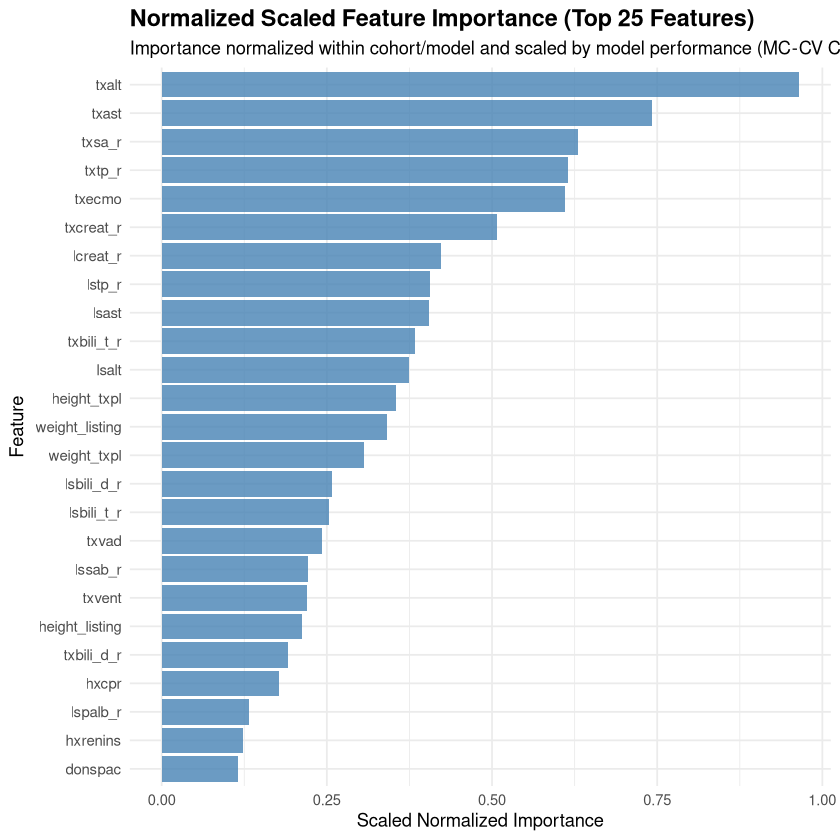

In [15]:
# 6.5 Normalized Scaled Feature Importance Bar Chart

# Create normalized scaled feature importance bar chart for top clinical features
# This chart shows feature importance normalized within each cohort/model and scaled by model performance (C-index)

library(ggplot2)
library(dplyr)

# Check if required files exist
output_dir_base <- here("cohort_analysis", "outputs", "survival")
summary_dir <- file.path(output_dir_base, "summary")

best_feat_path <- file.path(summary_dir, "best_clinical_features_by_cohort_mc_cv.csv")
metrics_path <- file.path(summary_dir, "cohort_model_cindex_mc_cv_modifiable_clinical.csv")

if (file.exists(best_feat_path) && file.exists(metrics_path)) {
  # Read data
  best_features <- readr::read_csv(best_feat_path, show_col_types = FALSE)
  cohort_metrics <- readr::read_csv(metrics_path, show_col_types = FALSE)
  
  # Prepare feature matrix: Cohort × Model × Feature
  feature_matrix <- best_features %>%
    dplyr::select(Cohort, Model, feature, importance) %>%
    dplyr::mutate(
      Cohort = as.character(Cohort),
      Model  = as.character(Model),
      importance = as.numeric(importance)
    ) %>%
    dplyr::mutate(importance = ifelse(is.na(importance), 0, importance)) %>%
    dplyr::group_by(Cohort, Model) %>%
    dplyr::mutate(
      importance = ifelse(importance < 0, 0, importance),
      total_imp = sum(importance),
      importance_normalized = ifelse(total_imp > 0, importance / total_imp, 1 / dplyr::n())
    ) %>%
    dplyr::select(-total_imp) %>%
    dplyr::ungroup()
  
  # Relative weights per cohort/model using C-index
  algorithm_ranking <- cohort_metrics %>%
    dplyr::select(Cohort, Model, C_Index_Mean) %>%
    dplyr::group_by(Cohort) %>%
    dplyr::mutate(
      best_cindex = max(C_Index_Mean, na.rm = TRUE),
      n_models = sum(!is.na(C_Index_Mean))
    ) %>%
    dplyr::ungroup() %>%
    dplyr::mutate(
      rel_weight = ifelse(best_cindex > 0,
                          (C_Index_Mean / best_cindex) * n_models,
                          1)
    ) %>%
    dplyr::select(Cohort, Model, rel_weight)
  
  feature_matrix <- feature_matrix %>%
    dplyr::left_join(algorithm_ranking, by = c("Cohort", "Model")) %>%
    dplyr::mutate(
      rel_weight = ifelse(is.na(rel_weight), 1, rel_weight),
      importance_scaled = importance_normalized * rel_weight
    )
  
  # Create scaled feature importance bar chart (Top 25 features)
  scaled_feature_importance <- feature_matrix %>%
    dplyr::group_by(feature) %>%
    dplyr::summarise(
      total_scaled_importance = sum(importance_scaled, na.rm = TRUE),
      .groups = "drop"
    ) %>%
    dplyr::arrange(desc(total_scaled_importance)) %>%
    dplyr::slice_head(n = 25)
  
  scaled_feature_importance <- scaled_feature_importance %>%
    dplyr::mutate(feature = factor(feature, levels = rev(scaled_feature_importance$feature)))
  
  p <- ggplot(scaled_feature_importance, aes(x = feature, y = total_scaled_importance)) +
    geom_bar(stat = "identity", fill = "steelblue", alpha = 0.8) +
    coord_flip() +
    labs(
      title = "Normalized Scaled Feature Importance (Top 25 Features)",
      subtitle = "Importance normalized within cohort/model and scaled by model performance (MC-CV C-index)",
      x = "Feature",
      y = "Scaled Normalized Importance"
    ) +
    theme_minimal() +
    theme(
      plot.title = element_text(size = 14, face = "bold"),
      plot.subtitle = element_text(size = 11),
      axis.text.y = element_text(size = 9)
    )
  
  # Display the plot
  print(p)
  
  # Also save to summary/plots directory
  plot_dir_summary <- file.path(summary_dir, "plots")
  dir.create(plot_dir_summary, showWarnings = FALSE, recursive = TRUE)
  
  ggplot2::ggsave(file.path(plot_dir_summary, "scaled_feature_importance_bar_chart.png"), p,
                  width = 12, height = 10, dpi = 300)
  cat("\n✓ Saved normalized scaled feature importance bar chart to:", 
      file.path(plot_dir_summary, "scaled_feature_importance_bar_chart.png"), "\n")
  
} else {
  cat("Required files not found. Please run Sections 6.3-6.4 first to generate:\n")
  cat("  -", best_feat_path, "\n")
  cat("  -", metrics_path, "\n")
  if (!file.exists(best_feat_path)) {
    cat("\nNote: Feature importance extraction may need to be added to the MC-CV code.\n")
  }
}


In [ ]:
# Create C-index comparison table
cindex_comparison <- map_df(period_names, function(period) {
  map_df(method_names, function(method) {
    result <- all_results[[period]][[method]]
    tibble(
      period = period,
      method = method,
      cindex_td_mean = result$cindex_td_mean,
      cindex_td_sd = result$cindex_td_sd,
      cindex_td_ci_lower = result$cindex_td_ci_lower,
      cindex_td_ci_upper = result$cindex_td_ci_upper,
      cindex_ti_mean = result$cindex_ti_mean,
      cindex_ti_sd = result$cindex_ti_sd,
      cindex_ti_ci_lower = result$cindex_ti_ci_lower,
      cindex_ti_ci_upper = result$cindex_ti_ci_upper,
      n_splits = result$n_successful
    )
  })
})

# Save to full_analysis subdirectory (consistent with other Section 5 outputs)
full_analysis_dir <- file.path(output_dir, "full_analysis")
dir.create(full_analysis_dir, showWarnings = FALSE, recursive = TRUE)

write_csv(cindex_comparison, file.path(full_analysis_dir, "cindex_comparison_mc_cv.csv"))
cat("✓ Saved: cindex_comparison_mc_cv.csv\n")

# Display the table
print(cindex_comparison)


✓ Saved: cindex_comparison_mc_cv.csv
# A tibble: 15 × 2
   period        method    
   <chr>         <chr>     
 1 original      RSF       
 2 original      AORSF     
 3 original      CatBoost  
 4 original      XGBoost   
 5 original      XGBoost_RF
 6 full          RSF       
 7 full          AORSF     
 8 full          CatBoost  
 9 full          XGBoost   
10 full          XGBoost_RF
11 full_no_covid RSF       
12 full_no_covid AORSF     
13 full_no_covid CatBoost  
14 full_no_covid XGBoost   
15 full_no_covid XGBoost_RF


In [ ]:
# Create summary statistics
summary_stats <- map_df(period_names, function(period) {
  period_data <- periods[[period]]
  tibble(
    period = period,
    n_patients = nrow(period_data),
    n_events = sum(period_data$outcome_graft_loss, na.rm = TRUE),
    event_rate = 100 * sum(period_data$outcome_graft_loss, na.rm = TRUE) / nrow(period_data)
  )
})

# Save to full_analysis subdirectory (consistent with other Section 5 outputs)
full_analysis_dir <- file.path(output_dir, "full_analysis")
dir.create(full_analysis_dir, showWarnings = FALSE, recursive = TRUE)

write_csv(summary_stats, file.path(full_analysis_dir, "summary_statistics_mc_cv.csv"))
cat("✓ Saved: summary_statistics_mc_cv.csv\n")

# Display the table
print(summary_stats)


✓ Saved: summary_statistics_mc_cv.csv
# A tibble: 3 × 4
  period        n_patients n_events event_rate
  <chr>              <int>    <dbl>      <dbl>
1 original            4036      768       19.0
2 full                5835      939       16.1
3 full_no_covid       4196      774       18.4


In [18]:
# Close parallel processing
plan(sequential)

cat("\n========================================\n")
cat("Analysis Complete!\n")
cat("========================================\n")
cat(sprintf("Output directory: %s\n", output_dir))
cat(sprintf("MC-CV splits: %d\n", n_mc_splits))
cat(sprintf("Train/Test ratio: %.0f/%.0f\n", train_prop * 100, (1 - train_prop) * 100))
cat("\nResults show C-indexes with 95% confidence intervals\n")
cat("based on", n_mc_splits, "independent train/test splits.\n\n")
cat("✓ All files saved successfully!\n")



Analysis Complete!
Output directory: /home/pgx3874/graft-loss/cohort_analysis/outputs/survival
MC-CV splits: 100
Train/Test ratio: 75/25

Results show C-indexes with 95% confidence intervals
based on 100 independent train/test splits.

✓ All files saved successfully!


### 6.6 Visualize Cohort Comparison Results

Create visualization plots for cohort modifiable features analysis comparing cohorts using the summary folder files.

In [25]:
# 6.6 Visualize Cohort Comparison Results

# Create visualization plots for cohort modifiable features analysis
# This creates visualizations comparing cohorts using the summary folder files
# Visualizations are saved to summary/plots/ for cross-cohort comparisons

library(here)

# Ensure output_dir_base is defined (should already exist from Section 6.3, but define if needed)
if (!exists("output_dir_base")) {
  output_dir_base <- here("cohort_analysis", "outputs", "survival")
}

# Verify the path exists and contains the expected files
summary_dir_check <- file.path(output_dir_base, "summary")
if (!dir.exists(summary_dir_check)) {
  stop("Summary directory not found: ", summary_dir_check, 
       "\nPlease run Sections 6.3-6.4 first to generate cohort MC-CV results.")
}

# Source the visualization script
if (!file.exists(here("scripts", "R", "create_visualizations_cohort.R"))) {
  stop("Cannot find scripts/R/create_visualizations_cohort.R. Ensure scripts are in scripts/R/ directory.")
}
source(here("scripts", "R", "create_visualizations_cohort.R"))

# Run visualizations using the base output directory
# CRITICAL: Must pass output_dir_base which points to "outputs/survival" 
# so that summary_dir becomes "outputs/survival/summary" (not "outputs/summary")
cat("Running visualizations with output_dir:", output_dir_base, "\n")
cat("Expected summary_dir:", summary_dir_check, "\n")

run_visualizations(output_dir = output_dir_base)

cat("\n✓ Cohort comparison visualizations saved to:", file.path(output_dir_base, "summary", "plots"), "\n")
cat("  - Feature importance heatmap\n")
cat("  - C-index heatmap\n")
cat("  - Scaled feature importance bar chart\n")
cat("  - C-index table\n")
cat("  - Cohort clinical feature Sankey diagram\n")
cat("  - Scaled normalized feature importance Sankey diagram\n")


→ Cleaning 1 existing plot files...
✓ Summary plots directory cleaned
→ Reading cohort MC-CV results...


Rows: 10 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Cohort, Model
dbl (5): C_Index_Mean, C_Index_SD, C_Index_CI_Lower, C_Index_CI_Upper, n_splits

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 77 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (8): Cohort, Model, feature, Base_Feature, Category, Potential_Intervent...
dbl (7): C_Index_Mean, C_Index_SD, C_Index_CI_Lower, C_Index_CI_Upper, n_spl...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Algorithm relative weights (by clinical cohort):
# A tibble: 10 × 3
   Cohort    Model      rel_weight
   <chr>     <chr>           <dbl>
 1 CHD       RSF              3.97
 2 CHD       AORSF            3.77
 3 CHD       CatBoost         5   
 4 CHD       XGBoost          4.18
 5 CHD       XGBoost_RF       3.98
 6 MyoCardio RSF              4.10
 7 MyoCardio AORSF            3.85
 8 MyoCardio CatBoost         5   
 9 MyoCardio XGBoost          4.11
10 MyoCardio XGBoost_RF       4.06

→ Creating feature importance heatmap...
✓ Saved: feature_importance_heatmap.png

→ Creating C-index heatmap...
✓ Saved: cindex_heatmap.png

→ Creating scaled feature importance bar chart...
✓ Saved: scaled_feature_importance_bar_chart.png

→ Creating C-index table...
✓ Saved: cindex_table.csv

→ Creating cohort clinical feature Sankey diagram (raw importance)...
✓ Saved: cohort_clinical_feature_sankey.html

→ Creating scaled normalized feature importance Sankey diagram...


Warning message:
“'layout' objects don't have these attributes: 'subtitle'
Valid attributes include:
'_deprecated', 'activeshape', 'annotations', 'autosize', 'autotypenumbers', 'calendar', 'clickmode', 'coloraxis', 'colorscale', 'colorway', 'computed', 'datarevision', 'dragmode', 'editrevision', 'editType', 'font', 'geo', 'grid', 'height', 'hidesources', 'hoverdistance', 'hoverlabel', 'hovermode', 'images', 'legend', 'mapbox', 'margin', 'meta', 'metasrc', 'modebar', 'newshape', 'paper_bgcolor', 'plot_bgcolor', 'polar', 'scene', 'selectdirection', 'selectionrevision', 'separators', 'shapes', 'showlegend', 'sliders', 'smith', 'spikedistance', 'template', 'ternary', 'title', 'transition', 'uirevision', 'uniformtext', 'updatemenus', 'width', 'xaxis', 'yaxis', 'barmode', 'bargap', 'mapType'
”


✓ Saved: cohort_scaled_feature_importance_sankey.html
✓ Saved: cohort_scaled_contribution_summary.csv

Visualization Summary
Combined cohort comparison plots saved to: /home/pgx3874/graft-loss/cohort_analysis/outputs/survival/summary/plots
Running visualizations with output_dir: /home/pgx3874/graft-loss/cohort_analysis/outputs/survival 
Expected summary_dir: /home/pgx3874/graft-loss/cohort_analysis/outputs/survival/summary 
→ Cleaning 39 existing plot files...
✓ Summary plots directory cleaned
→ Reading cohort MC-CV results...


Rows: 10 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Cohort, Model
dbl (5): C_Index_Mean, C_Index_SD, C_Index_CI_Lower, C_Index_CI_Upper, n_splits

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 77 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (8): Cohort, Model, feature, Base_Feature, Category, Potential_Intervent...
dbl (7): C_Index_Mean, C_Index_SD, C_Index_CI_Lower, C_Index_CI_Upper, n_spl...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Algorithm relative weights (by clinical cohort):
# A tibble: 10 × 3
   Cohort    Model      rel_weight
   <chr>     <chr>           <dbl>
 1 CHD       RSF              3.97
 2 CHD       AORSF            3.77
 3 CHD       CatBoost         5   
 4 CHD       XGBoost          4.18
 5 CHD       XGBoost_RF       3.98
 6 MyoCardio RSF              4.10
 7 MyoCardio AORSF            3.85
 8 MyoCardio CatBoost         5   
 9 MyoCardio XGBoost          4.11
10 MyoCardio XGBoost_RF       4.06

→ Creating feature importance heatmap...
✓ Saved: feature_importance_heatmap.png

→ Creating C-index heatmap...
✓ Saved: cindex_heatmap.png

→ Creating scaled feature importance bar chart...
✓ Saved: scaled_feature_importance_bar_chart.png

→ Creating C-index table...
✓ Saved: cindex_table.csv

→ Creating cohort clinical feature Sankey diagram (raw importance)...
✓ Saved: cohort_clinical_feature_sankey.html

→ Creating scaled normalized feature importance Sankey diagram...


Warning message:
“'layout' objects don't have these attributes: 'subtitle'
Valid attributes include:
'_deprecated', 'activeshape', 'annotations', 'autosize', 'autotypenumbers', 'calendar', 'clickmode', 'coloraxis', 'colorscale', 'colorway', 'computed', 'datarevision', 'dragmode', 'editrevision', 'editType', 'font', 'geo', 'grid', 'height', 'hidesources', 'hoverdistance', 'hoverlabel', 'hovermode', 'images', 'legend', 'mapbox', 'margin', 'meta', 'metasrc', 'modebar', 'newshape', 'paper_bgcolor', 'plot_bgcolor', 'polar', 'scene', 'selectdirection', 'selectionrevision', 'separators', 'shapes', 'showlegend', 'sliders', 'smith', 'spikedistance', 'template', 'ternary', 'title', 'transition', 'uirevision', 'uniformtext', 'updatemenus', 'width', 'xaxis', 'yaxis', 'barmode', 'bargap', 'mapType'
”


✓ Saved: cohort_scaled_feature_importance_sankey.html
✓ Saved: cohort_scaled_contribution_summary.csv

Visualization Summary
Combined cohort comparison plots saved to: /home/pgx3874/graft-loss/cohort_analysis/outputs/survival/summary/plots

✓ Cohort comparison visualizations saved to: /home/pgx3874/graft-loss/cohort_analysis/outputs/survival/summary/plots 
  - Feature importance heatmap
  - C-index heatmap
  - Scaled feature importance bar chart
  - C-index table
  - Cohort clinical feature Sankey diagram
  - Scaled normalized feature importance Sankey diagram


## 7. Sync Results and Code to S3

Sync output files and code (notebook + R script) to S3 bucket after all analyses and visualizations are complete.
- Outputs: CSV results files, plots, and visualizations
- Code: Notebook and R script for reproducibility


In [21]:
# Sync outputs and code to S3
# On EC2, we're in the cohort_analysis directory
s3_bucket <- "s3://uva-private-data-lake/graft-loss/cohort_analysis/survival/"

# Find AWS CLI (check common locations - EC2 typically has it in /usr/local/bin or /usr/bin)
aws_cmd <- Sys.which("aws")
if (aws_cmd == "") {
  # Try common EC2 installation paths
  aws_paths <- c(
    "/usr/local/bin/aws",
    "/usr/bin/aws",
    "/home/ec2-user/.local/bin/aws"
  )
  aws_cmd <- NULL
  for (path in aws_paths) {
    if (file.exists(path)) {
      aws_cmd <- path
      break
    }
  }
  if (is.null(aws_cmd)) {
    stop("AWS CLI not found. Please install AWS CLI or ensure it's in your PATH.")
  }
}

cat("Syncing outputs and code to S3...\n")
cat("Source: cohort_analysis/ directory\n")
cat("Destination:", s3_bucket, "\n")
cat("AWS CLI:", aws_cmd, "\n\n")

# Get current directory (should be cohort_analysis)
current_dir <- getwd()
if (!grepl("cohort_analysis", current_dir)) {
  warning("Current directory doesn't appear to be cohort_analysis. Double-check sync destination.")
}

# Sync survival outputs and code to S3
# Sync the outputs/survival directory specifically to avoid overwriting classification outputs
# Explicitly include notebook, R scripts, README files, and outputs/survival directory
# Exclude temporary files, checkpoints, and unnecessary directories
# Note: --delete flag removed for safety (won't delete files in S3 that don't exist locally)
sync_cmd <- sprintf(
  '"%s" s3 sync "%s" %s --include "*.ipynb" --include "*.R" --include "README*.md" --include "outputs/survival/**" --exclude "*checkpoint*" --exclude "*.tmp" --exclude "*.ipynb_checkpoints/*" --exclude "*.RData" --exclude "*.Rhistory" --exclude ".Rproj.user/*" --exclude "catboost_info/*" --exclude "*.log" --exclude "*"',
  aws_cmd,
  current_dir,
  s3_bucket
)

cat("Running:", sync_cmd, "\n\n")
result <- system(sync_cmd)

if (result == 0) {
  cat("✓ Successfully synced outputs and code to S3\n")
  cat("  - Outputs:", file.path(output_dir_base), "\n")
  cat("  - Code: *.ipynb, *.R, README*.md\n")
} else {
  warning(sprintf("S3 sync returned exit code %d. Check AWS credentials and permissions.", result))
}


Syncing outputs and code to S3...
Source: cohort_analysis/ directory
Destination: s3://uva-private-data-lake/graft-loss/cohort_analysis/survival/ 
AWS CLI: /usr/local/bin/aws 

Running: "/usr/local/bin/aws" s3 sync "/home/pgx3874/graft-loss/cohort_analysis" s3://uva-private-data-lake/graft-loss/cohort_analysis/survival/ --include "*.ipynb" --include "*.R" --include "README*.md" --include "outputs/survival/**" --exclude "*checkpoint*" --exclude "*.tmp" --exclude "*.ipynb_checkpoints/*" --exclude "*.RData" --exclude "*.Rhistory" --exclude ".Rproj.user/*" --exclude "catboost_info/*" --exclude "*.log" --exclude "*" 

✓ Successfully synced outputs and code to S3
  - Outputs: /home/pgx3874/graft-loss/cohort_analysis/outputs/survival 
  - Code: *.ipynb, *.R, README*.md


## 8. Shutdown EC2

Shutdown EC2 instance after all analyses, visualizations, and S3 sync are complete.


In [ ]:
# Shutdown EC2 instance after analysis completes
# Set SHUTDOWN_EC2 = TRUE to enable, FALSE to disable
SHUTDOWN_EC2 <- TRUE  # Change to TRUE to enable auto-shutdown

if (SHUTDOWN_EC2) {
  cat("\n========================================\n")
  cat("Shutting down EC2 instance...\n")
  cat("========================================\n")
  
  # Get instance ID from EC2 metadata service
  instance_id <- tryCatch({
    system("curl -s http://169.254.169.254/latest/meta-data/instance-id", intern = TRUE)
  }, error = function(e) {
    cat("Warning: Could not retrieve instance ID from metadata service.\n")
    cat("If running on EC2, check that metadata service is accessible.\n")
    return(NULL)
  })
  
  if (!is.null(instance_id) && length(instance_id) > 0 && nchar(instance_id[1]) > 0) {
    instance_id <- instance_id[1]
    cat(sprintf("Instance ID: %s\n", instance_id))
    
    # Find AWS CLI
    aws_cmd <- Sys.which("aws")
    if (aws_cmd == "") {
      aws_paths <- c(
        "/usr/local/bin/aws",
        "/usr/bin/aws",
        "/home/ec2-user/.local/bin/aws"
      )
      aws_cmd <- NULL
      for (path in aws_paths) {
        if (file.exists(path)) {
          aws_cmd <- path
          break
        }
      }
    }
    
    if (!is.null(aws_cmd) && aws_cmd != "") {
      # Stop the instance (use terminate-instances for permanent deletion)
      shutdown_cmd <- sprintf(
        '"%s" ec2 stop-instances --instance-ids %s',
        aws_cmd,
        instance_id
      )
      
      cat("Running:", shutdown_cmd, "\n")
      result <- system(shutdown_cmd)
      
      if (result == 0) {
        cat("✓ EC2 instance stop command sent successfully\n")
        cat("Instance will stop in a few moments.\n")
        cat("Note: This is a STOP (not terminate), so you can restart it later.\n")
      } else {
        warning(sprintf("EC2 stop command returned exit code %d. Check AWS credentials and permissions.", result))
      }
    } else {
      cat("Warning: AWS CLI not found. Cannot shutdown instance.\n")
      cat("Install AWS CLI or ensure it's in your PATH.\n")
    }
  } else {
    cat("Warning: Could not determine instance ID. Skipping shutdown.\n")
    cat("If you want to shutdown manually, use:\n")
    cat("  aws ec2 stop-instances --instance-ids <your-instance-id>\n")
  }
} else {
  cat("\n========================================\n")
  cat("EC2 Auto-Shutdown: DISABLED\n")
  cat("========================================\n")
  cat("To enable auto-shutdown, set SHUTDOWN_EC2 = TRUE in this cell.\n")
  cat("Instance will continue running.\n")
}
